In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.lines import Line2D


# =============================================================================
# COSTANTI FISICHE IN CGS
# =============================================================================

c = 2.99792458e10          # cm/s
G = 6.67430e-8             # cm^3 g^-1 s^-2
h = 6.62607015e-27         # erg s
kB = 1.380649e-16          # erg/K
sigma = 5.670374419e-5     # erg cm^-2 s^-1 K^-4
Msun = 1.98847e33          # g

eV_to_erg = 1.602176634e-12


# =============================================================================
# PARAMETRI DEL MODELLO SHAKURA-SUNYAEV
# =============================================================================

eta = 0.083

Nr = 2000
Nnu = 400

nu_min = 1e13
nu_max = 1e17


# =============================================================================
# PARAMETRI CASE B / OSTERBROCK
# =============================================================================

# Coefficiente totale di ricombinazione Case B
# T = 10^4 K
alpha_B = 2.59e-13     # cm^3 s^-1

# Coefficienti efficaci delle singole righe Balmer
alpha_eff = {
    "Ha": 1.16e-13,
    "Hb": 3.07e-14,
    "Hg": 1.29e-14,
    "Hd": 6.79e-15
}

# Lunghezze d'onda delle righe Balmer in Angstrom
lambda_balmer_A = {
    "Ha": 6563.0,
    "Hb": 4861.0,
    "Hg": 4340.0,
    "Hd": 4102.0
}

# Conversione delle lunghezze d'onda in cm
lambda_balmer_cm = {
    line_name: wavelength_A * 1e-8
    for line_name, wavelength_A in lambda_balmer_A.items()
}

# Frequenze delle righe Balmer emesse
nu_balmer_line = {
    line_name: c / wavelength_cm
    for line_name, wavelength_cm in lambda_balmer_cm.items()
}

# Soglia di ionizzazione dell'idrogeno
E_H_ion_eV = 13.6
E_H_ion_erg = E_H_ion_eV * eV_to_erg
nu_H_ion = E_H_ion_erg / h


# =============================================================================
# CLASSIFICAZIONE DELLE LINEE
# =============================================================================

BALMER_LINES = ["Ha", "Hb", "Hg", "Hd"]

METAL_LINES = ["MgII", "CIII", "CIV"]


# =============================================================================
# FILE DI INPUT
# =============================================================================

file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"


# =============================================================================
# SCENARI POSSIBILI PER MBH E mdot
# =============================================================================

SCENARI = [
    {
        "scenario": "MBH_5e8_mdot_0.01",
        "MBH_solar": 5e8,
        "mdot": 0.01
    },

    {
        "scenario": "MBH_5e8_mdot_0.1",
        "MBH_solar": 5e8,
        "mdot": 0.1
    },

    {
        "scenario": "MBH_1e9_mdot_0.01",
        "MBH_solar": 1e9,
        "mdot": 0.01
    },

    {
        "scenario": "MBH_1e9_mdot_0.1",
        "MBH_solar": 1e9,
        "mdot": 0.1
    }
]


# =============================================================================
# FUNZIONE PER TROVARE UNA COLONNA NEL DATAFRAME
# =============================================================================

def trova_colonna(df, possibili_nomi, obbligatoria=True):

    for nome in possibili_nomi:

        if nome in df.columns:
            return nome

    if obbligatoria:
        raise ValueError(
            f"Non trovo nessuna di queste colonne: {possibili_nomi}"
        )

    return None


# =============================================================================
# COSTRUZIONE DELLO SPETTRO DEL DISCO SHAKURA-SUNYAEV
# =============================================================================

def costruisci_spettro_disco(
    MBH_solar,
    mdot,
    eta=0.083,
    Nr=2000,
    Nnu=400,
    nu_min=1e13,
    nu_max=1e17
):

    """
    Costruisce lo spettro di un disco di accrescimento
    Shakura-Sunyaev.

    Parametri
    ----------
    MBH_solar : float
        Massa del buco nero in masse solari.

    mdot : float
        Tasso di accrescimento adimensionale.

    eta : float
        Efficienza radiativa.

    Restituisce
    -----------
    nu
        Griglia delle frequenze.

    Lnu
        Luminosità spettrale.

    nuLnu
        Quantità nu * Lnu.

    info
        Dizionario contenente i parametri fisici principali.
    """

    # Massa in grammi
    MBH = MBH_solar * Msun

    # Luminosità di Eddington
    Ledd = 1.3e38 * MBH_solar

    # Luminosità del disco
    Ldisk = mdot * Ledd

    # Tasso di accrescimento fisico in g/s
    Mdot = Ldisk / (eta * c**2)

    # Raggio di Schwarzschild
    Rs = 2.0 * G * MBH / c**2

    # Raggio interno
    Rin = 3.0 * Rs

    # Raggio esterno
    Rout = 3000.0 * Rs

    # Griglia radiale
    R = np.logspace(
        np.log10(Rin),
        np.log10(Rout),
        Nr
    )

    # Termine al bordo interno del disco
    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)

    # Profilo di temperatura
    T = (
        (
            3.0 * G * MBH * Mdot
        )
        /
        (
            8.0 * np.pi * sigma * R**3
        )
        * f
    )**0.25

    # Griglia in frequenza
    nu = np.logspace(
        np.log10(nu_min),
        np.log10(nu_max),
        Nnu
    )

    # Matrice della funzione di Planck
    Bnu = np.zeros((Nnu, Nr))

    for j in range(Nr):

        if T[j] <= 0:
            continue

        x = h * nu / (kB * T[j])

        x = np.clip(
            x,
            1e-12,
            700.0
        )

        Bnu[:, j] = (
            2.0 * h * nu**3 / c**2
        ) / (
            np.exp(x) - 1.0
        )

    # Integrale sul disco
    integrand = R[None, :] * Bnu

    I_nu = np.trapezoid(
        integrand,
        R,
        axis=1
    )

    # Luminosità spettrale totale del disco
    Lnu = 4.0 * np.pi**2 * I_nu

    nuLnu = nu * Lnu

    info = {
        "MBH_solar": MBH_solar,
        "MBH_g": MBH,
        "mdot": mdot,
        "Ledd": Ledd,
        "Ldisk": Ldisk,
        "Mdot": Mdot,
        "Rs": Rs,
        "Rin": Rin,
        "Rout": Rout
    }

    return nu, Lnu, nuLnu, info


# =============================================================================
# LETTURA DEL FILE dati.asc
# =============================================================================

def leggi_transizioni(file_transizioni):

    """
    Legge il file dati.asc.

    Il file contiene:

    line_name    E_ion    nu_ion

    Per MgII, CIII e CIV vengono mantenute le frequenze
    nu_ion presenti nel file.

    Per le Balmer questi valori NON vengono utilizzati
    come soglia di ionizzazione.
    """

    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )

    df = pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })

    return df


# =============================================================================
# CALCOLO DI Q(H)
# =============================================================================

def calcola_Q_H(
    nu,
    Lnu,
    nu_H_ion=nu_H_ion,
    nu_max=1e17
):

    """
    Calcola il numero di fotoni ionizzanti dell'idrogeno:

    Q(H) = integral Lnu / (h nu) dnu

    da 13.6 eV fino a nu_max.
    """

    mask = (
        (nu >= nu_H_ion)
        &
        (nu <= nu_max)
    )

    if np.sum(mask) < 2:
        return 0.0

    integrand = (
        Lnu[mask]
        /
        (h * nu[mask])
    )

    Q_H = np.trapezoid(
        integrand,
        nu[mask]
    )

    return Q_H


# =============================================================================
# LUMINOSITA' BALMER CON OSTERBROCK / CASE B
# =============================================================================

def calcola_luminosita_balmer_cf1(Q_H):

    """
    Calcola la luminosità teorica delle righe Balmer
    assumendo Cf = 1.

    L_line(Cf=1) =
        h * nu_line *
        (alpha_eff / alpha_B) *
        Q(H)
    """

    risultati = []

    for line_name in BALMER_LINES:

        nu_line = nu_balmer_line[line_name]

        alpha_line = alpha_eff[line_name]

        L_line_cf1 = (
            h
            * nu_line
            * (alpha_line / alpha_B)
            * Q_H
        )

        risultati.append({
            "line_name": line_name,
            "line_model": "Balmer_CaseB",
            "nu_line": nu_line,
            "nu_ion": nu_H_ion,
            "Q_H": Q_H,
            "L_ion": np.nan,
            "L_line_cf1": L_line_cf1
        })

    return pd.DataFrame(risultati)


# =============================================================================
# LUMINOSITA' IONIZZANTE PER MgII, CIII E CIV
# =============================================================================

def calcola_lion_metalli(
    nu,
    Lnu,
    df_trans,
    nu_max=1e17
):

    """
    Per MgII, CIII e CIV calcola:

    L_ion = integral Lnu dnu

    tra la nu_ion presente in dati.asc e nu_max.

    Nella prescrizione adottata:

    L_line = Cf * L_ion

    quindi per Cf = 1:

    L_line_cf1 = L_ion
    """

    risultati = []

    df_metalli = df_trans[
        df_trans["line_name"].isin(METAL_LINES)
    ].copy()

    for _, row in df_metalli.iterrows():

        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]

        if nu_ion >= nu_max:

            L_ion = 0.0

        else:

            mask = (
                (nu >= nu_ion)
                &
                (nu <= nu_max)
            )

            if np.sum(mask) < 2:

                L_ion = 0.0

            else:

                L_ion = np.trapezoid(
                    Lnu[mask],
                    nu[mask]
                )

        risultati.append({
            "line_name": line_name,
            "line_model": "Cf_times_Lion",
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "nu_line": np.nan,
            "Q_H": np.nan,
            "L_ion": L_ion,
            "L_line_cf1": L_ion
        })

    return pd.DataFrame(risultati)


# =============================================================================
# CALCOLO DI TUTTE LE LUMINOSITA' TEORICHE
# =============================================================================

def calcola_luminosita_teoriche(
    nu,
    Lnu,
    df_trans,
    nu_max=1e17
):

    """
    Calcola le luminosità teoriche Cf=1
    per tutte le linee.

    Balmer:
        Osterbrock / Case B

    MgII, CIII, CIV:
        integrale di Lnu sopra nu_ion.
    """

    # Q(H) comune a tutte le Balmer
    Q_H = calcola_Q_H(
        nu,
        Lnu,
        nu_H_ion=nu_H_ion,
        nu_max=nu_max
    )

    # Balmer
    df_balmer = calcola_luminosita_balmer_cf1(
        Q_H
    )

    # Metalli
    df_metalli = calcola_lion_metalli(
        nu,
        Lnu,
        df_trans,
        nu_max=nu_max
    )

    # Unisco tutto
    df_teorico = pd.concat(
        [
            df_balmer,
            df_metalli
        ],
        ignore_index=True,
        sort=False
    )

    return df_teorico, Q_H


# =============================================================================
# ESTRAZIONE DELLE LINEE OSSERVATE
# =============================================================================

def estrai_linee_osservate(
    row,
    norm_columns
):

    """
    Estrae le luminosità di riga osservate positive.

    I valori *_norm sono espressi in unità di
    10^42 erg/s.
    """

    risultati = []

    for col in norm_columns:

        valore = row[col]

        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace(
            "_norm",
            ""
        )

        # Considero soltanto le linee utilizzate dal modello
        if line_name not in BALMER_LINES + METAL_LINES:
            continue

        L_line_obs = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line_obs": L_line_obs
        })

    return pd.DataFrame(risultati)


# =============================================================================
# GRAFICO DELLO SPETTRO
# =============================================================================

def fai_grafico_spettro(
    nu,
    Lnu,
    df_trans,
    nome_blazar,
    scenario_name
):

    """
    Mostra lo spettro SS e le soglie utilizzate
    per il calcolo delle luminosità di riga.

    Per le Balmer viene mostrata una sola soglia:
    quella dell'idrogeno a 13.6 eV.

    Per MgII, CIII e CIV vengono mostrate le
    nu_ion presenti in dati.asc.
    """

    plt.figure(
        figsize=(9, 6)
    )

    plt.loglog(
        nu,
        Lnu,
        color="black",
        lw=2,
        label=r"$L_\nu$ disco"
    )

    # Soglia comune di ionizzazione dell'idrogeno
    plt.axvline(
        nu_H_ion,
        color="red",
        lw=2,
        linestyle="--",
        alpha=0.8,
        label="H ionizzazione (13.6 eV)"
    )

    # Frequenze di ionizzazione dei metalli
    cmap = plt.get_cmap("tab10")

    df_metalli = df_trans[
        df_trans["line_name"].isin(METAL_LINES)
    ].copy()

    for i, (_, row) in enumerate(
        df_metalli.iterrows()
    ):

        plt.axvline(
            row["nu_ion"],
            color=cmap(i),
            lw=1.5,
            alpha=0.8,
            label=row["line_name"]
        )

    plt.xlabel(
        r"$\nu$ [Hz]"
    )

    plt.ylabel(
        r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]"
    )

    plt.title(
        f"Spettro del disco - {nome_blazar} - {scenario_name}"
    )

    plt.xlim(
        nu.min(),
        nu.max()
    )

    plt.ylim(
        1e17,
        1e30
    )

    plt.legend(
        fontsize=8,
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left"
    )

    plt.tight_layout()

    plt.show()


# =============================================================================
# LETTURA DEI FILE
# =============================================================================

df_tab = pd.read_csv(
    file_linee
)

df_trans = leggi_transizioni(
    file_transizioni
)


# =============================================================================
# IDENTIFICAZIONE DELLE COLONNE UTILI
# =============================================================================

col_name_tab = trova_colonna(
    df_tab,
    [
        "label",
        "file_name",
        "name",
        "nome",
        "blazar"
    ]
)

norm_columns = [
    col
    for col in df_tab.columns
    if col.endswith("_norm")
]


# =============================================================================
# PREPARAZIONE DEL DATAFRAME
# =============================================================================

df_all = df_tab.rename(
    columns={
        col_name_tab: "label"
    }
).copy()


# =============================================================================
# CONTROLLO DELLE FREQUENZE UTILIZZATE
# =============================================================================

print("=" * 80)
print("FREQUENZE UTILIZZATE NEL MODELLO")
print("=" * 80)

print(
    f"Soglia H 13.6 eV = "
    f"{nu_H_ion:.4e} Hz"
)

print()

print("Frequenze delle righe Balmer emesse:")

for line_name in BALMER_LINES:

    print(
        f"{line_name:4s} | "
        f"lambda = {lambda_balmer_A[line_name]:.1f} A | "
        f"nu_line = {nu_balmer_line[line_name]:.4e} Hz"
    )

print()

print("Frequenze nu_ion dei metalli da dati.asc:")

for _, row in df_trans[
    df_trans["line_name"].isin(METAL_LINES)
].iterrows():

    print(
        f"{row['line_name']:4s} | "
        f"E = {row['E_ion']:.3f} eV | "
        f"nu_ion = {row['nu_ion']:.4e} Hz"
    )

print("=" * 80)


# =============================================================================
# ANALISI DI UN SINGOLO BLAZAR
# =============================================================================

def analizza_blazar(
    row,
    df_trans,
    norm_columns,
    mostra_grafico=True,
    verbose=True
):

    nome_blazar = row["label"]

    MBH_solar = row["MBH_solar"]

    mdot = row["mdot"]

    scenario_name = row["scenario"]

    if "redshift" in row.index:
        redshift = row["redshift"]
    else:
        redshift = np.nan

    if verbose:

        print("=" * 80)

        print(
            f"Scenario = {scenario_name}"
        )

        print(
            f"Blazar = {nome_blazar}"
        )

        print(
            f"redshift = {redshift}"
        )

        print(
            f"MBH = {MBH_solar:.3e} Msun"
        )

        print(
            f"mdot = {mdot:.5f}"
        )

    # -------------------------------------------------------------------------
    # SPETTRO DEL DISCO
    # -------------------------------------------------------------------------

    nu, Lnu, nuLnu, info = costruisci_spettro_disco(
        MBH_solar=MBH_solar,
        mdot=mdot,
        eta=eta,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max
    )

    if verbose:

        print()

        print(
            f"Ledd  = {info['Ledd']:.3e} erg/s"
        )

        print(
            f"Ldisk = {info['Ldisk']:.3e} erg/s"
        )

        print(
            f"Mdot  = {info['Mdot']:.3e} g/s"
        )

    # -------------------------------------------------------------------------
    # LUMINOSITA' TEORICHE DELLE LINEE
    # -------------------------------------------------------------------------

    df_teorico, Q_H = calcola_luminosita_teoriche(
        nu,
        Lnu,
        df_trans,
        nu_max=nu_max
    )

    if verbose:

        print()

        print(
            f"Q(H) = {Q_H:.6e} photons/s"
        )

    # -------------------------------------------------------------------------
    # LINEE OSSERVATE
    # -------------------------------------------------------------------------

    df_linee = estrai_linee_osservate(
        row,
        norm_columns
    )

    if verbose:

        print()
        print("Linee osservate del blazar:")

        display(
            df_linee
        )

    # -------------------------------------------------------------------------
    # CONFRONTO OSSERVATO - TEORICO
    # -------------------------------------------------------------------------

    df_conf = df_linee.merge(
        df_teorico,
        on="line_name",
        how="left"
    )

    # Covering factor richiesto
    #
    # Cf = L_obs / L_theory(Cf=1)

    df_conf["covering_factor"] = (
        df_conf["L_line_obs"]
        /
        df_conf["L_line_cf1"]
    )

    # Evito divisioni non fisiche
    df_conf.loc[
        (
            df_conf["L_line_cf1"].isna()
        )
        |
        (
            df_conf["L_line_cf1"] <= 0
        ),
        "covering_factor"
    ] = np.nan

    # Luminosità teorica che si avrebbe assumendo Cf = 0.1
    df_conf["L_line_Cf_0p1"] = (
        0.1
        * df_conf["L_line_cf1"]
    )

    # Rapporto modello / osservazione per Cf = 0.1
    df_conf["model_over_obs_Cf_0p1"] = (
        df_conf["L_line_Cf_0p1"]
        /
        df_conf["L_line_obs"]
    )

    if verbose:

        print()
        print("Confronto finale per ogni linea:")

        colonne_output = [
            "line_name",
            "line_model",
            "L_line_obs",
            "L_line_cf1",
            "L_line_Cf_0p1",
            "model_over_obs_Cf_0p1",
            "covering_factor",
            "Q_H",
            "L_ion"
        ]

        display(
            df_conf[colonne_output]
        )

    # -------------------------------------------------------------------------
    # GRAFICO
    # -------------------------------------------------------------------------

    if mostra_grafico:

        fai_grafico_spettro(
            nu,
            Lnu,
            df_trans,
            nome_blazar,
            scenario_name
        )

    return df_conf


# =============================================================================
# ANALISI DI TUTTI I BLAZAR NEI QUATTRO SCENARI
# =============================================================================

tutti_risultati_scenari = []

for scenario in SCENARI:

    df_all_scenario = df_all.copy()

    df_all_scenario["MBH_solar"] = (
        scenario["MBH_solar"]
    )

    df_all_scenario["mdot"] = (
        scenario["mdot"]
    )

    df_all_scenario["scenario"] = (
        scenario["scenario"]
    )

    risultati_scenario = []

    for i in range(
        len(df_all_scenario)
    ):

        row = df_all_scenario.iloc[i]

        df_conf = analizza_blazar(
            row,
            df_trans,
            norm_columns,
            mostra_grafico=False,
            verbose=False
        )

        df_conf["label"] = (
            row["label"]
        )

        df_conf["scenario"] = (
            scenario["scenario"]
        )

        df_conf["MBH_solar"] = (
            scenario["MBH_solar"]
        )

        df_conf["mdot"] = (
            scenario["mdot"]
        )

        risultati_scenario.append(
            df_conf
        )

    df_risultati_scenario = pd.concat(
        risultati_scenario,
        ignore_index=True
    )

    tutti_risultati_scenari.append(
        df_risultati_scenario
    )


# =============================================================================
# DATAFRAME FINALE
# =============================================================================

df_risultati_finali = pd.concat(
    tutti_risultati_scenari,
    ignore_index=True
)

FREQUENZE UTILIZZATE NEL MODELLO
Soglia H 13.6 eV = 3.2885e+15 Hz

Frequenze delle righe Balmer emesse:
Ha   | lambda = 6563.0 A | nu_line = 4.5679e+14 Hz
Hb   | lambda = 4861.0 A | nu_line = 6.1673e+14 Hz
Hg   | lambda = 4340.0 A | nu_line = 6.9077e+14 Hz
Hd   | lambda = 4102.0 A | nu_line = 7.3084e+14 Hz

Frequenze nu_ion dei metalli da dati.asc:
MgII | E = 7.600 eV | nu_ion = 1.8380e+15 Hz
CIII | E = 24.380 eV | nu_ion = 5.8900e+15 Hz
CIV  | E = 47.900 eV | nu_ion = 1.1580e+16 Hz


In [7]:
# =============================================================================
# TABELLE PER BLAZAR
# =============================================================================

tabelle_per_blazar = {}

blazar_unici = sorted(
    df_risultati_finali[
        "label"
    ].unique()
)

ordine_scenari = [
    s["scenario"]
    for s in SCENARI
]


for blazar in blazar_unici:

    df_blazar = df_risultati_finali[
        df_risultati_finali["label"]
        ==
        blazar
    ].copy()

    tabella_blazar = df_blazar.pivot(
        index="scenario",
        columns="line_name",
        values="covering_factor"
    )

    # Ordine fisico delle linee
    ordine_linee_tabella = [
        "Ha",
        "Hb",
        "Hg",
        "Hd",
        "MgII",
        "CIII",
        "CIV"
    ]

    colonne_presenti = [
        linea
        for linea in ordine_linee_tabella
        if linea in tabella_blazar.columns
    ]

    tabella_blazar = tabella_blazar[
        colonne_presenti
    ]

    # Ordine degli scenari
    tabella_blazar = (
        tabella_blazar
        .reindex(ordine_scenari)
        .reset_index()
    )

    tabella_blazar = (
        tabella_blazar.fillna("-")
    )

    tabelle_per_blazar[
        blazar
    ] = tabella_blazar


print(
    f"Tabelle create per blazar: "
    f"{len(tabelle_per_blazar)}"
)


# =============================================================================
# VISUALIZZAZIONE DELLE TABELLE PER BLAZAR
# =============================================================================

for blazar, tabella in tabelle_per_blazar.items():

    print(
        "\n" + "=" * 100
    )

    print(
        f"Blazar: {blazar}"
    )

    display(
        tabella
    )

Tabelle create per blazar: 13

Blazar: J0021.6-6835


line_name,scenario,Hb,Hg,Hd
0,MBH_5e8_mdot_0.01,9.609823,5.804932,7.498037
1,MBH_5e8_mdot_0.1,0.244672,0.147797,0.190905
2,MBH_1e9_mdot_0.01,9.591408,5.793809,7.483670
3,MBH_1e9_mdot_0.1,0.163894,0.099002,0.127878



Blazar: J0050.0-4458


line_name,scenario,Ha,Hb,Hg,Hd
0,MBH_5e8_mdot_0.01,0.174338,0.097814,0.171044,0.056075
1,MBH_5e8_mdot_0.1,0.004439,0.002490,0.004355,0.001428
2,MBH_1e9_mdot_0.01,0.174004,0.097626,0.170716,0.055968
3,MBH_1e9_mdot_0.1,0.002973,0.001668,0.002917,0.000956



Blazar: J0059.1-5701


...

line_name,scenario,Ha,Hb
0,MBH_5e8_mdot_0.01,1.898341,1.613615
1,MBH_5e8_mdot_0.1,0.048333,0.041084
2,MBH_1e9_mdot_0.01,1.894703,1.610523
3,MBH_1e9_mdot_0.1,0.032376,0.027520



Blazar: J1816.9-4944


line_name,scenario,MgII,CIII,CIV
0,MBH_5e8_mdot_0.01,0.025776,79.511559,1.054538e+05
1,MBH_5e8_mdot_0.1,0.001302,0.340674,9.700866e+00
2,MBH_1e9_mdot_0.01,0.017934,172.753025,1.245472e+06
3,MBH_1e9_mdot_0.1,0.000760,0.351185,2.503617e+01



Blazar: J2237.5-8326


line_name,scenario,Hb,Hg,Hd
0,MBH_5e8_mdot_0.01,10.640558,7.668595,0.632931
1,MBH_5e8_mdot_0.1,0.270915,0.195247,0.016115
2,MBH_1e9_mdot_0.01,10.620169,7.653900,0.631719
3,MBH_1e9_mdot_0.1,0.181473,0.130787,0.010795


In [8]:
# =============================================================================
# TABELLE PER SCENARIO
# =============================================================================

tabelle_per_scenario = {}

scenari_unici = [
    s["scenario"]
    for s in SCENARI
]


for scenario in scenari_unici:

    df_scenario = df_risultati_finali[
        df_risultati_finali["scenario"]
        ==
        scenario
    ].copy()

    tabella_scenario = df_scenario.pivot(
        index="label",
        columns="line_name",
        values="covering_factor"
    )

    ordine_linee_tabella = [
        "Ha",
        "Hb",
        "Hg",
        "Hd",
        "MgII",
        "CIII",
        "CIV"
    ]

    colonne_presenti = [
        linea
        for linea in ordine_linee_tabella
        if linea in tabella_scenario.columns
    ]

    tabella_scenario = tabella_scenario[
        colonne_presenti
    ]

    tabella_scenario = (
        tabella_scenario
        .reset_index()
        .fillna("-")
    )

    tabelle_per_scenario[
        scenario
    ] = tabella_scenario


# =============================================================================
# VISUALIZZAZIONE DELLE TABELLE PER SCENARIO
# =============================================================================

for scenario in scenari_unici:

    print(
        "\n" + "=" * 100
    )

    print(
        f"Scenario: {scenario}"
    )

    display(
        tabelle_per_scenario[
            scenario
        ]
    )


Scenario: MBH_5e8_mdot_0.01


line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,9.609823,5.804932,7.498037,-,-,-
1,J0050.0-4458,0.174338,0.097814,0.171044,0.056075,-,-,-
2,J0059.1-5701,-,-,133.72806,107.479015,0.294732,-,-
3,J0133.2-5159,-,-,-,102.083037,0.396984,-,-
4,J0508.2-1936,-,-,-,-,-,43.199347,594212.001571
5,J0922.8-3959,-,31.343781,33.928871,158.025257,1.104027,-,-
6,J1123.3-2529,1.134275,6.16988,5.262682,3.198418,-,-,-
7,J1329.4-0530,-,-,37.854129,232.177349,0.303112,-,-
8,J152422.56,-,-,-,1.233729,0.000877,0.042755,-
9,J170108.89,-,-,-,-,0.001174,0.298614,140.628256



Scenario: MBH_5e8_mdot_0.1


line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,0.244672,0.147797,0.190905,-,-,-
1,J0050.0-4458,0.004439,0.00249,0.004355,0.001428,-,-,-
2,J0059.1-5701,-,-,3.404797,2.73648,0.014893,-,-
3,J0133.2-5159,-,-,-,2.599096,0.020059,-,-
4,J0508.2-1936,-,-,-,-,-,0.185091,54.662549
5,J0922.8-3959,-,0.798032,0.863849,4.023418,0.055786,-,-
6,J1123.3-2529,0.028879,0.157089,0.133991,0.081434,-,-,-
7,J1329.4-0530,-,-,0.963789,5.911375,0.015316,-,-
8,J152422.56,-,-,-,0.031411,0.000044,0.000183,-
9,J170108.89,-,-,-,-,0.000059,0.001279,0.012937



Scenario: MBH_1e9_mdot_0.01


line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,9.591408,5.793809,7.48367,-,-,-
1,J0050.0-4458,0.174004,0.097626,0.170716,0.055968,-,-,-
2,J0059.1-5701,-,-,133.471811,107.273065,0.205061,-,-
3,J0133.2-5159,-,-,-,101.887426,0.276203,-,-
4,J0508.2-1936,-,-,-,-,-,93.858277,7017997.100168
5,J0922.8-3959,-,31.283721,33.863857,157.72245,0.768131,-,-
6,J1123.3-2529,1.132101,6.158057,5.252598,3.192289,-,-,-
7,J1329.4-0530,-,-,37.781593,231.732451,0.210891,-,-
8,J152422.56,-,-,-,1.231365,0.00061,0.092892,-
9,J170108.89,-,-,-,-,0.000817,0.648792,1660.903332



Scenario: MBH_1e9_mdot_0.1


line_name,label,Ha,Hb,Hg,Hd,MgII,CIII,CIV
0,J0021.6-6835,-,0.163894,0.099002,0.127878,-,-,-
1,J0050.0-4458,0.002973,0.001668,0.002917,0.000956,-,-,-
2,J0059.1-5701,-,-,2.280713,1.833039,0.008685,-,-
3,J0133.2-5159,-,-,-,1.741012,0.011699,-,-
4,J0508.2-1936,-,-,-,-,-,0.190802,141.074081
5,J0922.8-3959,-,0.534564,0.578652,2.695098,0.032535,-,-
6,J1123.3-2529,0.019345,0.105226,0.089754,0.054549,-,-,-
7,J1329.4-0530,-,-,0.645597,3.959751,0.008932,-,-
8,J152422.56,-,-,-,0.021041,0.000026,0.000189,-
9,J170108.89,-,-,-,-,0.000035,0.001319,0.033387


CHECK DATI PER IL GRAFICO
Numero punti: 156
Blazar presenti: ['J0021', 'J0050', 'J0059', 'J0133', 'J0508', 'J0922', 'J1123', 'J1329', 'J1745', 'J1816', 'J2237', 'J152422', 'J170108']
Scenari presenti: ['MBH_5e8_mdot_0.01' 'MBH_5e8_mdot_0.1' 'MBH_1e9_mdot_0.01'
 'MBH_1e9_mdot_0.1']
Linee presenti: ['Ha' 'Hb' 'Hg' 'Hd' 'CIV' 'CIII' 'MgII']
Cf min: 2.58320153745291e-05
Cf max: 7017997.100168269


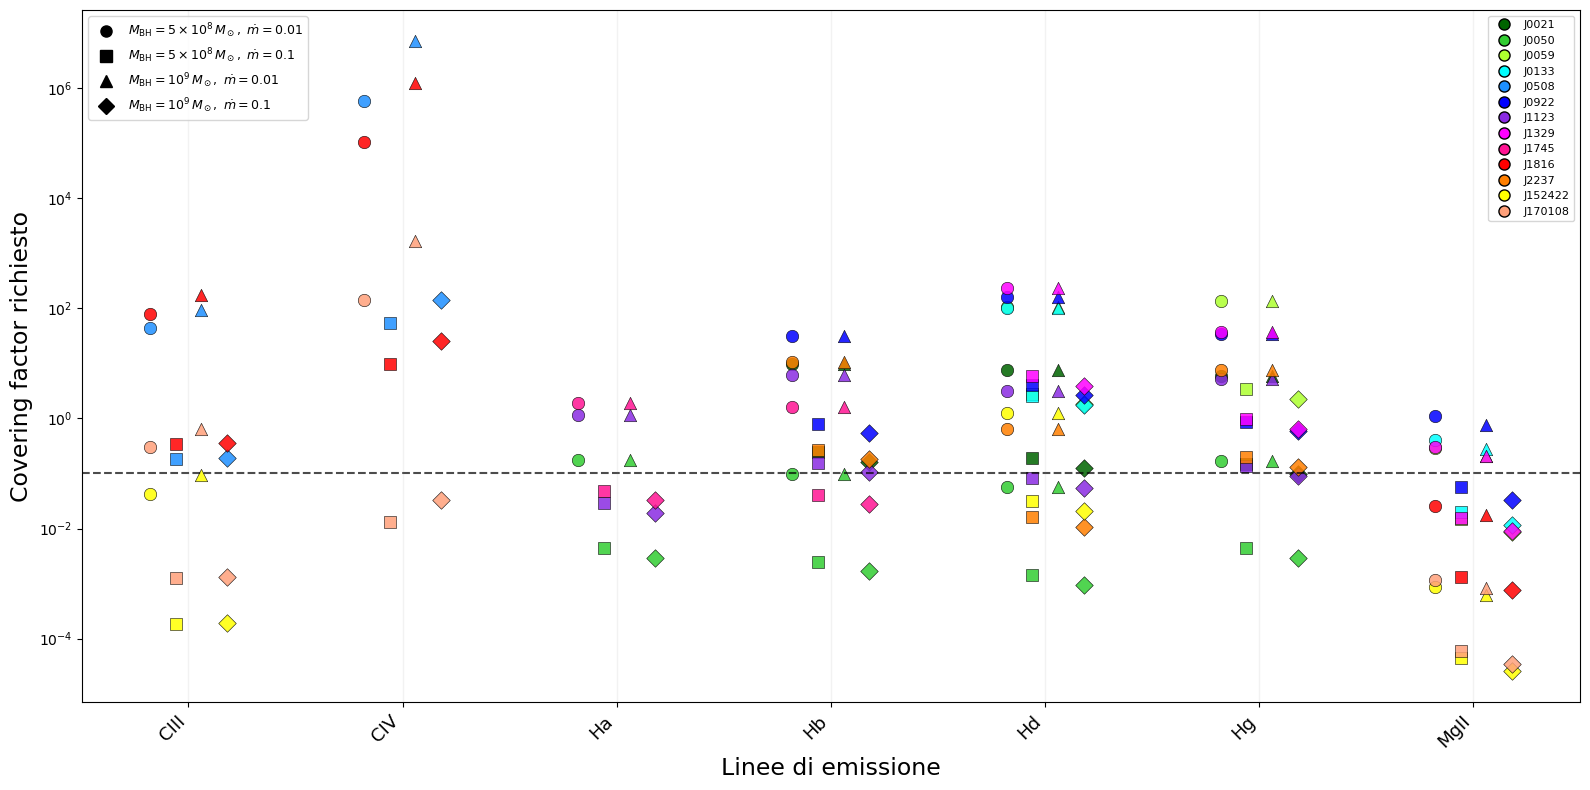

In [ ]:
# =============================================================================
# GRAFICO GENERALE DEI COVERING FACTOR
# =============================================================================

df_plot = df_risultati_finali.copy()


# Converto Cf in numerico
df_plot["covering_factor"] = pd.to_numeric(
    df_plot["covering_factor"],
    errors="coerce"
)


# Tengo solo Cf validi e positivi
df_plot = df_plot[
    df_plot["covering_factor"].notna()
    &
    (df_plot["covering_factor"] > 0)
].copy()


# =============================================================================
# ORDINE DELLE LINEE
# =============================================================================

ordine_linee = [
    "CIII",
    "CIV",
    "Ha",
    "Hb",
    "Hd",
    "Hg",
    "MgII"
]


linee_presenti = (
    df_plot["line_name"]
    .dropna()
    .unique()
    .tolist()
)


linee_uniche = [
    linea
    for linea in ordine_linee
    if linea in linee_presenti
]


linee_uniche += [
    linea
    for linea in sorted(linee_presenti)
    if linea not in linee_uniche
]


x_map = {
    linea: i
    for i, linea in enumerate(linee_uniche)
}


df_plot["x_base"] = (
    df_plot["line_name"]
    .map(x_map)
)


# =============================================================================
# OFFSET DEI QUATTRO SCENARI
# =============================================================================

offset_scenario = {
    ordine_scenari[0]: -0.18,
    ordine_scenari[1]: -0.06,
    ordine_scenari[2]:  0.06,
    ordine_scenari[3]:  0.18
}


df_plot["x"] = (
    df_plot["x_base"]
    +
    df_plot["scenario"].map(offset_scenario)
)


# =============================================================================
# NOMI CORTI E COLORI DEI BLAZAR
# =============================================================================

blazar_order = [
    "J0021",
    "J0050",
    "J0059",
    "J0133",
    "J0508",
    "J0922",
    "J1123",
    "J1329",
    "J1745",
    "J1816",
    "J2237",
    "J152422",
    "J170108"
]

colors = [
    "#006400",
    "#32cd32",
    "#adff2f",
    "#00ffff",
    "#1e90ff",
    "#0000ff",
    "#8a2be2",
    "#ff00ff",
    "#ff1493",
    "#ff0000",
    "#ff7f00",
    "#ffff00",
    "#ffa07a"
]


def trova_nome_corto(label):
    label = str(label)

    for blazar in blazar_order:
        if label.startswith(blazar):
            return blazar

    return label


df_plot["blazar_short"] = df_plot["label"].apply(trova_nome_corto)


color_map = dict(zip(blazar_order, colors))


# Tengo solo i blazar effettivamente presenti nel dataframe,
# mantenendo l'ordine scelto
ordine_blazar = [
    blazar
    for blazar in blazar_order
    if blazar in df_plot["blazar_short"].unique()
]


print("CHECK DATI PER IL GRAFICO")
print("Numero punti:", len(df_plot))
print("Blazar presenti:", ordine_blazar)
print("Scenari presenti:", df_plot["scenario"].unique())
print("Linee presenti:", df_plot["line_name"].unique())
print("Cf min:", df_plot["covering_factor"].min())
print("Cf max:", df_plot["covering_factor"].max())


# =============================================================================
# SIMBOLI DEGLI SCENARI
# =============================================================================

marker_map = {
    ordine_scenari[0]: "o",
    ordine_scenari[1]: "s",
    ordine_scenari[2]: "^",
    ordine_scenari[3]: "D"
}


scenario_label_map = {
    ordine_scenari[0]:
        r"$M_{\rm BH}=5\times10^8\,M_\odot,\ \dot{m}=0.01$",

    ordine_scenari[1]:
        r"$M_{\rm BH}=5\times10^8\,M_\odot,\ \dot{m}=0.1$",

    ordine_scenari[2]:
        r"$M_{\rm BH}=10^9\,M_\odot,\ \dot{m}=0.01$",

    ordine_scenari[3]:
        r"$M_{\rm BH}=10^9\,M_\odot,\ \dot{m}=0.1$"
}


# =============================================================================
# CREAZIONE DEL GRAFICO
# =============================================================================

fig, ax = plt.subplots(figsize=(16, 8))


for scenario in ordine_scenari:

    df_s = df_plot[
        df_plot["scenario"] == scenario
    ]

    for blazar in ordine_blazar:

        df_b = df_s[
            df_s["blazar_short"] == blazar
        ]

        if df_b.empty:
            continue

        ax.scatter(
            df_b["x"],
            df_b["covering_factor"],
            color=color_map[blazar],
            marker=marker_map[scenario],
            s=80,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.45
        )


# =============================================================================
# ASPETTO DEGLI ASSI
# =============================================================================

ax.set_yscale("log")


ax.axhline(
    0.1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)


ax.set_xticks(range(len(linee_uniche)))

ax.set_xticklabels(
    linee_uniche,
    rotation=45,
    ha="right",
    fontsize=13
)


ax.set_xlabel(
    "Linee di emissione",
    fontsize=17
)

ax.set_ylabel(
    "Covering factor",
    fontsize=17
)


for i in range(len(linee_uniche)):
    ax.axvline(
        i,
        color="gray",
        alpha=0.10,
        lw=1
    )


# =============================================================================
# LEGENDA DEGLI SCENARI
# =============================================================================

legend_scenari = [
    Line2D(
        [0],
        [0],
        marker=marker_map[scenario],
        color="black",
        linestyle="None",
        markersize=8,
        label=scenario_label_map[scenario]
    )
    for scenario in ordine_scenari
]


leg1 = ax.legend(
    handles=legend_scenari,
    loc="upper left",
    fontsize=9,
    frameon=True
)

ax.add_artist(leg1)


# =============================================================================
# LEGENDA DEI BLAZAR
# =============================================================================

legend_blazar = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_map[blazar],
        markeredgecolor="black",
        markersize=8,
        linestyle="None",
        label=blazar
    )
    for blazar in ordine_blazar
]


ax.legend(
    handles=legend_blazar,
    loc="upper right",
    fontsize=8,
    frameon=True
)


plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# CHECK DIAGNOSTICO DEI QUATTRO SCENARI
# =============================================================================

print("\n")
print("=" * 120)
print("CHECK DIAGNOSTICO DEGLI SPETTRI SHAKURA-SUNYAEV")
print("=" * 120)


for scenario in SCENARI:

    scenario_name = scenario["scenario"]
    MBH_solar = scenario["MBH_solar"]
    mdot = scenario["mdot"]

    print("\n")
    print("-" * 120)
    print(f"SCENARIO: {scenario_name}")
    print("-" * 120)

    print(f"MBH  = {MBH_solar:.4e} Msun")
    print(f"mdot = {mdot:.4e}")


    # -------------------------------------------------------------------------
    # COSTRUZIONE DELLO SPETTRO
    # -------------------------------------------------------------------------

    nu, Lnu, nuLnu, info = costruisci_spettro_disco(
        MBH_solar=MBH_solar,
        mdot=mdot,
        eta=eta,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max
    )


    # -------------------------------------------------------------------------
    # CONTROLLO DELLA LUMINOSITA' TOTALE DELLO SPETTRO
    # -------------------------------------------------------------------------

    L_spectrum = np.trapezoid(
        Lnu,
        nu
    )

    L_disk = info["Ldisk"]

    rapporto_spectrum_disk = (
        L_spectrum / L_disk
        if L_disk > 0
        else np.nan
    )


    print("\nCONTROLLO NORMALIZZAZIONE SPETTRO")

    print(
        f"Ledd       = {info['Ledd']:.6e} erg/s"
    )

    print(
        f"Ldisk      = {L_disk:.6e} erg/s"
    )

    print(
        f"∫Lnu dnu   = {L_spectrum:.6e} erg/s"
    )

    print(
        f"Lspec/Ldisk = {rapporto_spectrum_disk:.6f}"
    )


    # -------------------------------------------------------------------------
    # CALCOLO Q(H)
    # -------------------------------------------------------------------------

    Q_H = calcola_Q_H(
        nu,
        Lnu,
        nu_H_ion=nu_H_ion,
        nu_max=nu_max
    )


    print("\nFOTONI IONIZZANTI DELL'IDROGENO")

    print(
        f"nu_H_ion = {nu_H_ion:.6e} Hz"
    )

    print(
        f"Q(H)     = {Q_H:.6e} photons/s"
    )


    # -------------------------------------------------------------------------
    # CALCOLO DELLE LUMINOSITA' IONIZZANTI DEI METALLI
    # -------------------------------------------------------------------------

    df_metalli_check = calcola_lion_metalli(
        nu,
        Lnu,
        df_trans,
        nu_max=nu_max
    )


    print("\nLUMINOSITA' IONIZZANTI DEI METALLI")

    for _, row_metal in df_metalli_check.iterrows():

        print(
            f"{row_metal['line_name']:4s} | "
            f"nu_ion = {row_metal['nu_ion']:.6e} Hz | "
            f"L_ion = {row_metal['L_ion']:.6e} erg/s"
        )


    # -------------------------------------------------------------------------
    # LUMINOSITA' BALMER PER Cf = 1 E Cf = 0.1
    # -------------------------------------------------------------------------

    df_balmer_check = calcola_luminosita_balmer_cf1(
        Q_H
    )


    print("\nLUMINOSITA' BALMER TEORICHE")

    for _, row_balmer in df_balmer_check.iterrows():

        L_cf1 = row_balmer["L_line_cf1"]
        L_cf01 = 0.1 * L_cf1

        print(
            f"{row_balmer['line_name']:4s} | "
            f"L(Cf=1) = {L_cf1:.6e} erg/s | "
            f"L(Cf=0.1) = {L_cf01:.6e} erg/s"
        )


print("\n")
print("=" * 120)
print("FINE CHECK DIAGNOSTICO")
print("=" * 120)



CHECK DIAGNOSTICO DEGLI SPETTRI SHAKURA-SUNYAEV


------------------------------------------------------------------------------------------------------------------------
SCENARIO: MBH_5e8_mdot_0.01
------------------------------------------------------------------------------------------------------------------------
MBH  = 5.0000e+08 Msun
mdot = 1.0000e-02

CONTROLLO NORMALIZZAZIONE SPETTRO
Ledd       = 6.500000e+46 erg/s
Ldisk      = 6.500000e+44 erg/s
∫Lnu dnu   = 6.505984e+44 erg/s
Lspec/Ldisk = 1.000921

FOTONI IONIZZANTI DELL'IDROGENO
nu_H_ion = 3.288465e+15 Hz
Q(H)     = 1.411278e+54 photons/s

LUMINOSITA' IONIZZANTI DEI METALLI
MgII | nu_ion = 1.838000e+15 Hz | L_ion = 1.802075e+44 erg/s
CIII | nu_ion = 5.890000e+15 Hz | L_ion = 1.628573e+42 erg/s
CIV  | nu_ion = 1.158000e+16 Hz | L_ion = 7.024551e+38 erg/s

LUMINOSITA' BALMER TEORICHE
Ha   | L(Cf=1) = 1.913132e+42 erg/s | L(Cf=0.1) = 1.913132e+41 erg/s
Hb   | L(Cf=1) = 6.836002e+41 erg/s | L(Cf=0.1) = 6.836002e+40 erg/s
Hg 